![dvd_image](dvd_image.jpg)

A DVD rental company needs your help! They want to figure out how many days a customer will rent a DVD for based on some features and has approached you for help. They want you to try out some regression models which will help predict the number of days a customer will rent a DVD for. The company wants a model which yeilds a MSE of 3 or less on a test set. The model you make will help the company become more efficient inventory planning.

The data they provided is in the csv file `rental_info.csv`. It has the following features:
- `"rental_date"`: The date (and time) the customer rents the DVD.
- `"return_date"`: The date (and time) the customer returns the DVD.
- `"amount"`: The amount paid by the customer for renting the DVD.
- `"amount_2"`: The square of `"amount"`.
- `"rental_rate"`: The rate at which the DVD is rented for.
- `"rental_rate_2"`: The square of `"rental_rate"`.
- `"release_year"`: The year the movie being rented was released.
- `"length"`: Lenght of the movie being rented, in minuites.
- `"length_2"`: The square of `"length"`.
- `"replacement_cost"`: The amount it will cost the company to replace the DVD.
- `"special_features"`: Any special features, for example trailers/deleted scenes that the DVD also has.
- `"NC-17"`, `"PG"`, `"PG-13"`, `"R"`: These columns are dummy variables of the rating of the movie. It takes the value 1 if the move is rated as the column name and 0 otherwise. For your convinience, the reference dummy has already been dropped.

## Load libraries and general setup

In [225]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import seaborn as sns
import matplotlib.pyplot as plt

## Import data and formatting

In [226]:
rental_df = pd.read_csv("rental_info.csv")
rental_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15861 entries, 0 to 15860
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_date       15861 non-null  object 
 1   return_date       15861 non-null  object 
 2   amount            15861 non-null  float64
 3   release_year      15861 non-null  float64
 4   rental_rate       15861 non-null  float64
 5   length            15861 non-null  float64
 6   replacement_cost  15861 non-null  float64
 7   special_features  15861 non-null  object 
 8   NC-17             15861 non-null  int64  
 9   PG                15861 non-null  int64  
 10  PG-13             15861 non-null  int64  
 11  R                 15861 non-null  int64  
 12  amount_2          15861 non-null  float64
 13  length_2          15861 non-null  float64
 14  rental_rate_2     15861 non-null  float64
dtypes: float64(8), int64(4), object(3)
memory usage: 1.8+ MB


In [227]:
rental_df['rental_date'] = pd.to_datetime(rental_df['rental_date'])
rental_df['return_date'] = pd.to_datetime(rental_df['return_date'])

rental_df['rental_length_days'] = (rental_df['return_date'] - rental_df['rental_date']).dt.days
rental_df.head(5)

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,3
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,7
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,4


In [228]:
rental_df['deleted_scenes'] = rental_df['special_features'].str.contains("Deleted Scenes").astype(int)
rental_df['behind_the_scenes'] = rental_df['special_features'].str.contains("Behind the Scenes").astype(int)

rental_df.head()

,rental_date,return_date,amount,release_year,rental_rate,length,replacement_cost,special_features,NC-17,PG,PG-13,R,amount_2,length_2,rental_rate_2,rental_length_days,deleted_scenes,behind_the_scenes
0,2005-05-25 02:54:33+00:00,2005-05-28 23:40:33+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,3,0,1
1,2005-06-15 23:19:16+00:00,2005-06-18 19:24:16+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2,0,1
2,2005-07-10 04:27:45+00:00,2005-07-17 10:11:45+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,7,0,1
3,2005-07-31 12:06:41+00:00,2005-08-02 14:30:41+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,2,0,1
4,2005-08-19 12:30:04+00:00,2005-08-23 13:35:04+00:00,2.99,2005.0,2.99,126.0,16.99,"{Trailers,""Behind the Scenes""}",0,0,0,1,8.9401,15876.0,8.9401,4,0,1


## Model setup

In [229]:
X = rental_df.drop(['rental_date', 'return_date', 'special_features', 'rental_length_days'], axis = 1)
y = rental_df['rental_length_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9)

In [230]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Evaluation of linear models

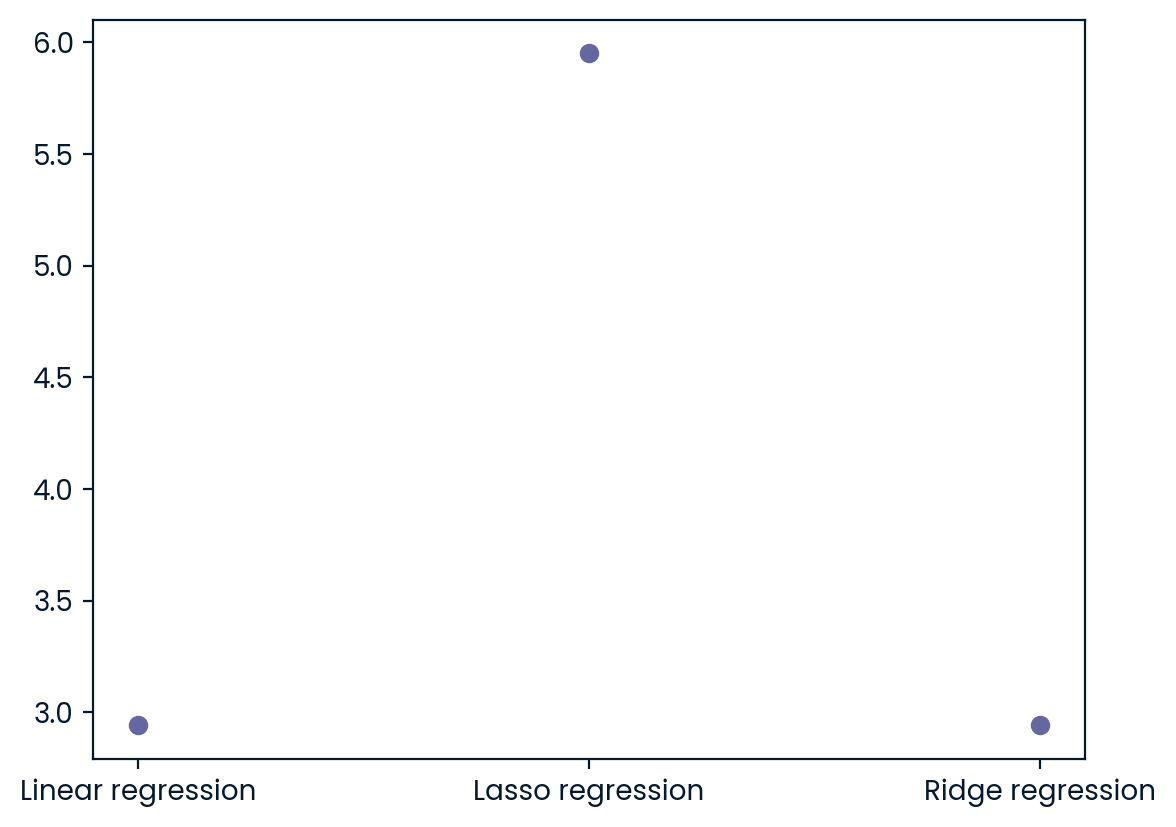

,model,MSE
0,Linear regression,2.941724
1,Lasso regression,5.949585
2,Ridge regression,2.941871


In [231]:
linear_models = {'Linear regression': LinearRegression(),
          'Lasso regression': Lasso(),
          'Ridge regression': Ridge()}

mse_scores = []

for model in linear_models.values():    
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse_scores.append(mean_squared_error(y_test, y_pred))

plt.scatter(y = mse_scores, x =linear_models.keys())
plt.show()

results_linear = pd.DataFrame({
    'model': linear_models.keys(),
    'MSE': mse_scores
})
results_linear.head()

### Evaluation of non-linear models

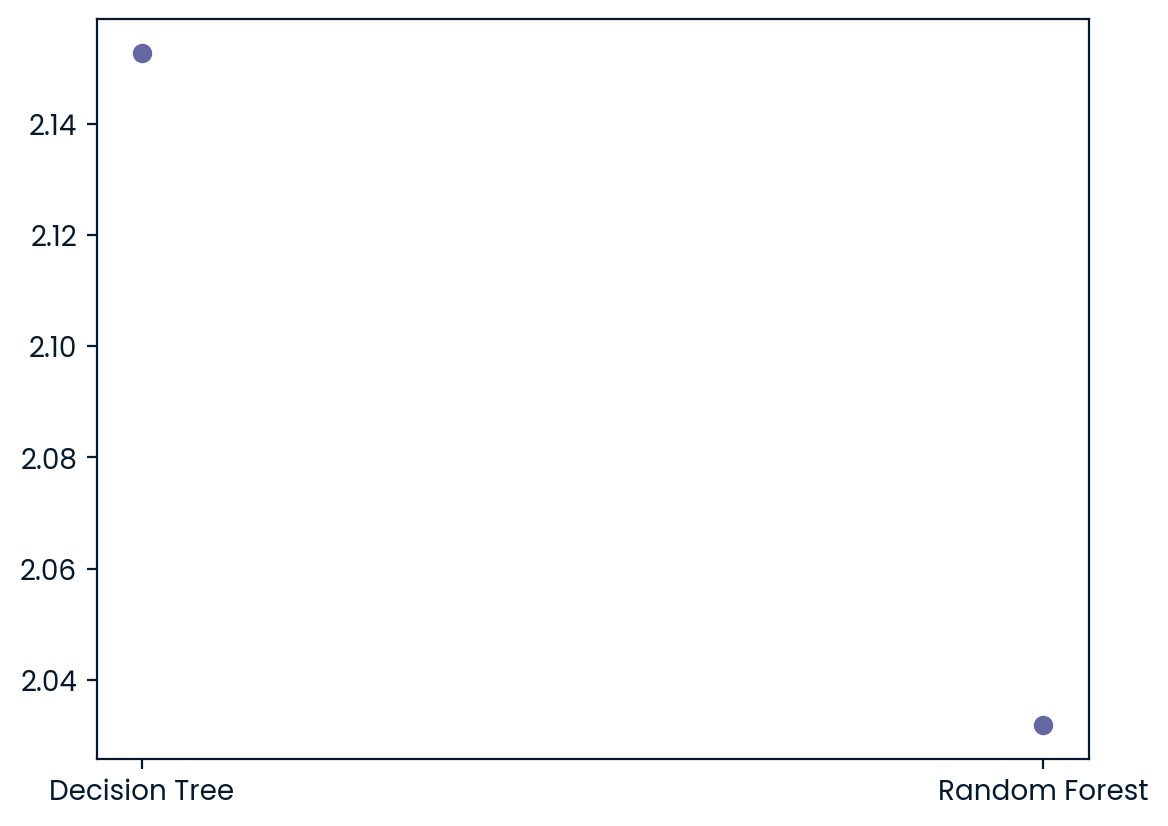

,model,MSE
0,Decision Tree,2.152745
1,Random Forest,2.031881


In [232]:
tree_models = {'Decision Tree': DecisionTreeRegressor(),
               'Random Forest': RandomForestRegressor()}

mse_scores_trees = []

for model in tree_models.values():    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse_scores_trees.append(mean_squared_error(y_test, y_pred))

plt.scatter(y = mse_scores_trees, x = tree_models.keys())
plt.show()

results_trees = pd.DataFrame({
    'model': tree_models.keys(),
    'MSE': mse_scores_trees
})
results_trees.head()

## Model comparison

In [233]:
results = pd.concat([results_linear, results_trees]).sort_values('MSE').reset_index(drop=True)
results

,model,MSE
0,Random Forest,2.031881
1,Decision Tree,2.152745
2,Linear regression,2.941724
3,Ridge regression,2.941871
4,Lasso regression,5.949585


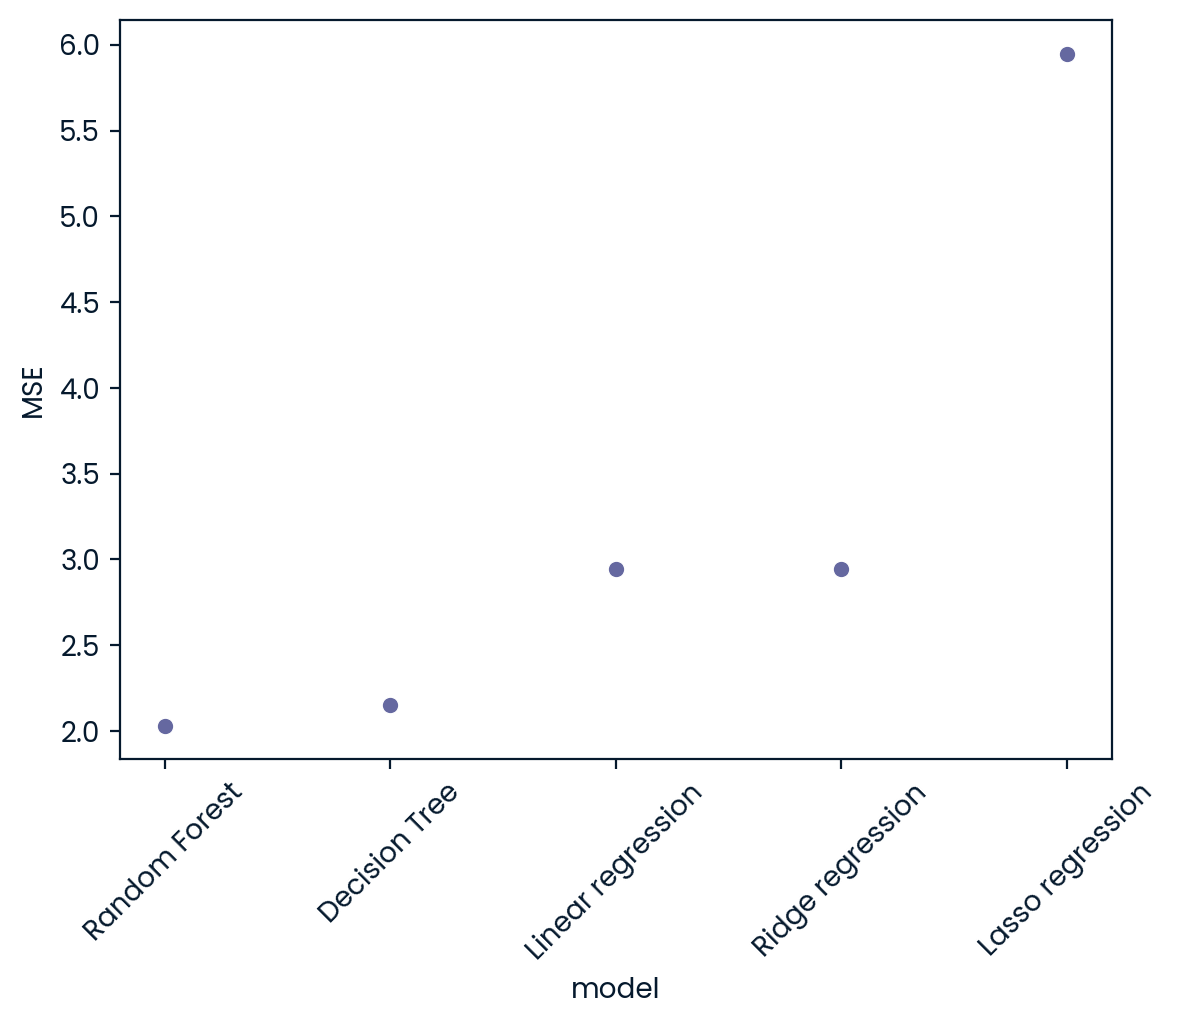

In [234]:
sns.scatterplot(x='model', y='MSE', data=results)
plt.xticks(rotation=45)
plt.show()

## Fine-tuning Random Forest model

In [235]:
best_model = tree_models['Random Forest']
best_mse = results.loc[results['model'] == "Random Forest", 'MSE'].item()
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}
rf_cv = RandomizedSearchCV(best_model, param_grid, n_iter=20, scoring='neg_mean_squared_error', cv = 5, n_jobs = -1, random_state = 9)

rf_cv.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=9, scoring='neg_mean_squared_error')

In [236]:
print("Best parameters:", rf_cv.best_params_)

# Predictions on test set after fine tuning
y_pred = rf_cv.best_estimator_.predict(X_test)
best_mse = mean_squared_error(y_test, y_pred)
print("Best MSE:", best_mse)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Best MSE: 2.0242907173565503


## Conclusions
I approached this project with both linear and non-linear models to compare their performance without any hyperparameter tuning. Results show that Random Forest was the best model, after fine tuning, its performance increase slightly. Goes to show that even when applied directly to this type of context, it is a powerful model.